# MPTrj data attributes and trainer-like EDA

This notebook independently inspects the MPTrj ASE-LMDB data in the same style used by `EquiformerV3DeNSTrainer`: load `AseDBDataset`, request energy/forces/stress from `AtomsToGraphs`, batch with `data_list_collater(..., otf_graph=True)`, and build the periodic radius graph on the fly.

The goal is to separate raw dataset attributes, model inputs, derived graph inputs, training labels, and DeNS-only attributes. The earlier Gemini explanation is useful as a checklist, but every statement below is meant to be checked against this repo's loader/model behavior and live samples.

## High-level answer

For the MPTrj direct EquiformerV3 config, the main input state is an atomic crystal structure: atomic numbers, Cartesian positions, periodic cell, periodic boundary flags, and batching indices. The model does not read precomputed edges from the dataset because `otf_graph: True`; instead it derives periodic edges, edge vectors, edge distances, cell offsets, and per-system neighbor counts during forward with `max_radius=6.0` and `max_neighbors=300`.

The supervised labels are total uncorrected energy per structure, per-atom force vectors, and per-structure stress tensors. The trainer can also create a DeNS auxiliary target by corrupting positions with Gaussian noise; in that mode, selected atoms use `noise_vec` as the force-head target while uncorrupted atoms still use the physical force target.

In [1]:
from __future__ import annotations

import copy
import math
import os
import sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Make the notebook runnable whether Jupyter starts in the repo root or in experimental/datasets.
cwd = Path.cwd().resolve()
repo_candidates = [cwd, *cwd.parents]
REPO_ROOT = next(path for path in repo_candidates if (path / "src" / "fairchem").exists())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))
os.chdir(REPO_ROOT)

from ase.data import chemical_symbols
from fairchem.core.datasets import AseDBDataset
from fairchem.core.datasets.lmdb_dataset import data_list_collater
from fairchem.core.common.utils import get_pbc_distances, radius_graph_pbc
from fairchem.experimental.trainers.equiformer_v3_dens_trainer import add_gaussian_noise_to_position

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)

print(f"Repo root: {REPO_ROOT}")

/home/ryoji/miniconda3/envs/equiformer_v3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repo root: /home/ryoji/equivarient/equiformer_v3


## Configuration mirrored from training

The training config uses `format: ase_db`, `a2g_args: {r_energy: True, r_forces: True, r_stress: True}`, `otf_graph: True`, `use_pbc: True`, `use_pbc_single: True`, `max_radius: 6.0`, and `max_neighbors: 300`. The default `AseAtomsDataset` path also forces `r_pbc=True`, leaves `r_edges=False` unless explicitly requested, keeps `r_fixed=True`, and applies `apply_one_tags`, which sets all tags to `1` when a structure has no tags.

In [2]:
# Prefer the local 160k subset used by the metadata notebook. Switch to the full path when desired.
DATASET_DIR = REPO_ROOT / "dataset" / "mptrj" / "aselmdb_uncorrected_total_energy_160k"
# DATASET_DIR = REPO_ROOT / "dataset" / "mptrj" / "aselmdb_uncorrected_total_energy"

CONFIG_PATH = REPO_ROOT / "experimental" / "configs" / "omat24" / "mptrj" / "experiments" / "direct" / "equiformer_v3_N@7_L@4_attn-hidden@32_rbf@10_max-neighbors@300_attn-grid@14-8_ffn-grid@14_use-gate-force-head_merge-layer-norm_epochs@70-bs@512-wd@1e-3-beta2@0.95_dens-p@0.5-std@0.025-r@0.5-w@10-strict-max-r@0.75-no-stress.yml"

CUTOFF = 6.0
MAX_NEIGHBORS = 300
USE_PBC_SINGLE = True
ENFORCE_MAX_NEIGHBORS_STRICTLY = True

SAMPLE_SIZE = 5_000          # Number of structures for attribute distributions.
GRAPH_SAMPLE_SIZE = 512      # Number of structures for on-the-fly edge distributions.
GRAPH_BATCH_SIZE = 16        # Keep small because periodic graph construction can be memory hungry.
BATCH_SIZE = 8
SEED = 0

assert DATASET_DIR.exists(), f"Dataset directory does not exist: {DATASET_DIR}"
print(DATASET_DIR)

/home/ryoji/equivarient/equiformer_v3/dataset/mptrj/aselmdb_uncorrected_total_energy_160k


In [3]:
dataset_config = {
    "src": str(DATASET_DIR),
    "a2g_args": {
        "r_energy": True,
        "r_forces": True,
        "r_stress": True,
        # r_pbc is set to True by AseAtomsDataset even if omitted.
        # r_edges stays False by default because EquiformerV3 uses otf_graph=True.
    },
}

dataset = AseDBDataset(dataset_config)
print(f"Loaded {len(dataset):,} structures")
print(f"Training config exists: {CONFIG_PATH.exists()}")

Loaded 160,000 structures
Training config exists: True


## Attribute map

| Attribute | Typical single sample shape | Batched shape | Role | Detailed meaning |
| --- | ---: | ---: | --- | --- |
| `atomic_numbers` | `[N]`, `uint8` | `[sum_N]` | Explicit model input | Atomic number Z for each atom. EquiformerV3 casts this to `long`, uses it in the atom embedding, and optionally uses source/target element embeddings in edge radial features. |
| `pos` | `[N, 3]`, float32 | `[sum_N, 3]` | Explicit model input | Wrapped Cartesian coordinates in Angstrom. Used to construct the periodic graph, edge vectors, distances, rotations, and spherical harmonics. In DeNS training, the trainer may add Gaussian noise to selected free atoms. |
| `cell` | `[1, 3, 3]` | `[B, 3, 3]` | Explicit model input | Lattice vectors for periodic images. Needed to compute PBC offsets and distances. |
| `pbc` | `[3]`, bool | `[3B]` | Explicit model input for graph building | Periodicity flags for each cell axis. MPTrj preprocessing creates periodic crystal structures, so this is usually all true. PyG flattens it in a batch. |
| `natoms` | int | `[B]` | Batching and graph input | Number of atoms per structure. Used by batching, graph construction, and metrics/loss reshaping. In this repo's `metadata.npz`, the key is also called `natoms`, but it may contain edge counts after metadata replacement for load balancing. |
| `batch`, `ptr` | absent before batching | `[sum_N]`, `[B+1]` | PyG batching input | `batch` maps each atom to its structure index; `ptr` stores atom start offsets. Created by `Batch.from_data_list`. |
| `edge_index`, `cell_offsets`, `edge_distance`, `edge_distance_vec`, `neighbors` | derived | derived | Derived graph inputs | Not stored in MPTrj because `otf_graph=True`. The model builds them from `pos`, `cell`, `pbc`, and `natoms` during forward. |
| `energy` | scalar float | `[B]` | System label | Total uncorrected energy in eV from MPTrj preprocessing. The training config uses element references and target normalization before computing the energy loss. |
| `forces` | `[N, 3]` | `[sum_N, 3]` | Atom label; DeNS conditioning input only in DeNS mode | Physical force vectors in eV/A. Normal training uses them as atom labels. In DeNS mode, the DeNS model embeds true forces on selected noisy atoms and the trainer constructs a hybrid target of physical forces and noise vectors. |
| `stress` | `[3, 3]` | `[3B, 3]` | System label | Stress tensor in eV/A^3. The conversion script multiplies MPTrj kBar stress by `-0.1 * ase.units.GPa`, both converting units and applying ASE sign convention. The model returns stress as `[B, 9]`. |
| `fixed` | `[N]`, int | `[sum_N]` | Trainer mask | `1` means fixed atom, `0` means free atom. The trainer masks atom-level force loss/evaluation to free atoms when configured. MPTrj bulk structures normally have no fixed atoms. |
| `tags` | `[N]`, int | `[sum_N]` | Mostly metadata here | ASE atom tags. Because MPTrj structures do not carry OC20 adsorbate/surface tags, the default transform sets tags to all `1`; EquiformerV3 does not use tags in this code path. |
| `sid` | string | list-like `[B]` | Metadata | Structure identifier from preprocessing, such as `mp-1217811-1-0`. Useful for tracing back to MPTrj entries. |
| `fid` | tensor `[1]` | `[B]` | Metadata | Frame ID. Defaults to zero here unless present in ASE `atoms.info`. |
| `noise_vec`, `noise_mask`, `dens_batch_mask`, `denoising_pos_forward` | absent in raw data | added by trainer | DeNS-only training attributes | Created on the fly by `add_gaussian_noise_to_position`, not stored in the dataset. `noise_vec` is the denoising target for noisy atoms; `noise_mask` selects corrupted atoms; `dens_batch_mask` selects structures where DeNS is active. |

## Inspect one raw sample and one trainer-like batch

A raw `AseDBDataset` item is a PyG `Data` object. A training step receives a PyG `DataBatch` created with `data_list_collater(..., otf_graph=True)`, so it has `batch` and `ptr` but still has no stored `edge_index`.

In [4]:
sample = dataset[0]
print(sample)
print("keys:", sorted(sample.keys()))

for key in sorted(sample.keys()):
    value = sample[key]
    if torch.is_tensor(value):
        print(f"{key:>16}: shape={tuple(value.shape)!s:>12} dtype={value.dtype}")
    else:
        print(f"{key:>16}: {type(value).__name__} value={value}")

print("unique tags:", torch.unique(sample.tags, return_counts=True))
print("unique fixed:", torch.unique(sample.fixed, return_counts=True))

Data(pos=[2, 3], cell=[1, 3, 3], atomic_numbers=[2], natoms=2, tags=[2], sid='mp-1217811-1-0', energy=-24.86681267, forces=[2, 3], stress=[3, 3], fixed=[2], pbc=[3], fid=[1])
keys: ['atomic_numbers', 'cell', 'energy', 'fid', 'fixed', 'forces', 'natoms', 'pbc', 'pos', 'sid', 'stress', 'tags']
  atomic_numbers: shape=        (2,) dtype=torch.uint8
            cell: shape=   (1, 3, 3) dtype=torch.float32
          energy: float value=-24.86681267
             fid: shape=        (1,) dtype=torch.int64
           fixed: shape=        (2,) dtype=torch.int32
          forces: shape=      (2, 3) dtype=torch.float32
          natoms: int value=2
             pbc: shape=        (3,) dtype=torch.bool
             pos: shape=      (2, 3) dtype=torch.float32
             sid: str value=mp-1217811-1-0
          stress: shape=      (3, 3) dtype=torch.float32
            tags: shape=        (2,) dtype=torch.int32
unique tags: (tensor([1], dtype=torch.int32), tensor([2]))
unique fixed: (tensor([0], dty

In [5]:
batch = data_list_collater([dataset[i] for i in range(BATCH_SIZE)], otf_graph=True)
print(batch)
print("keys:", sorted(batch.keys()))
print("natoms:", batch.natoms.tolist())
print("cell shape:", tuple(batch.cell.shape))
print("pbc shape:", tuple(batch.pbc.shape), "reshaped:", batch.pbc.view(-1, 3).tolist())
print("stress shape:", tuple(batch.stress.shape), "reshaped:", tuple(batch.stress.view(-1, 3, 3).shape))
print("batch shape:", tuple(batch.batch.shape), "ptr:", batch.ptr.tolist())

DataBatch(pos=[224, 3], cell=[8, 3, 3], atomic_numbers=[224], natoms=[8], tags=[224], sid=[8], energy=[8], forces=[224, 3], stress=[24, 3], fixed=[224], pbc=[24], fid=[8], batch=[224], ptr=[9])
keys: ['atomic_numbers', 'batch', 'cell', 'energy', 'fid', 'fixed', 'forces', 'natoms', 'pbc', 'pos', 'ptr', 'sid', 'stress', 'tags']
natoms: [2, 8, 34, 44, 66, 38, 12, 20]
cell shape: (8, 3, 3)
pbc shape: (24,) reshaped: [[True, True, True], [True, True, True], [True, True, True], [True, True, True], [True, True, True], [True, True, True], [True, True, True], [True, True, True]]
stress shape: (24, 3) reshaped: (8, 3, 3)
batch shape: (224,) ptr: [0, 2, 10, 44, 88, 154, 192, 204, 224]


## Trainer-like DeNS augmentation check

`noise_vec`, `noise_mask`, `dens_batch_mask`, and `denoising_pos_forward` are not dataset attributes. They are created by the trainer just before forward. This cell applies the same helper used in `equiformer_v3_dens_trainer.py` to one batch so the added attributes can be inspected.

In [6]:
dens_batch = copy.deepcopy(batch)
dens_batch = add_gaussian_noise_to_position(
    dens_batch,
    std=0.025,
    corrupt_ratio=0.5,
    all_atoms=False,
    strict_max_ratio=0.75,
)

print("denoising_pos_forward:", dens_batch.denoising_pos_forward)
print("noise_vec:", tuple(dens_batch.noise_vec.shape), dens_batch.noise_vec.dtype)
print("noise_mask true atoms:", int(dens_batch.noise_mask.sum()), "/", dens_batch.noise_mask.numel())
print("dens_batch_mask:", dens_batch.dens_batch_mask.tolist())
print("mean nonzero noise norm:", float(dens_batch.noise_vec.norm(dim=1)[dens_batch.noise_mask].mean()))

denoising_pos_forward: True
noise_vec: (224, 3) torch.float32
noise_mask true atoms: 112 / 224
dens_batch_mask: [True, True, True, True, True, True, True, True]
mean nonzero noise norm: 0.039618976414203644


## Collect sample-level statistics

This section samples structures from the ASE-LMDB, not just metadata arrays. Increase `SAMPLE_SIZE` if you want smoother distributions.

In [7]:
rng = np.random.default_rng(SEED)
sample_size = min(SAMPLE_SIZE, len(dataset))
sample_indices = np.sort(rng.choice(len(dataset), size=sample_size, replace=False))
sample_indices[:10], sample_size

(array([ 30,  35,  47,  58,  92, 108, 207, 302, 369, 382]), 5000)

In [8]:
def as_numpy(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def cell_lengths_angles(cell_3x3: np.ndarray):
    a_vec, b_vec, c_vec = cell_3x3
    a = np.linalg.norm(a_vec)
    b = np.linalg.norm(b_vec)
    c = np.linalg.norm(c_vec)

    def angle(u, v):
        denom = np.linalg.norm(u) * np.linalg.norm(v)
        if denom == 0:
            return np.nan
        cos_val = np.clip(np.dot(u, v) / denom, -1.0, 1.0)
        return np.degrees(np.arccos(cos_val))

    alpha = angle(b_vec, c_vec)
    beta = angle(a_vec, c_vec)
    gamma = angle(a_vec, b_vec)
    volume = abs(np.linalg.det(cell_3x3))
    return a, b, c, alpha, beta, gamma, volume


def collect_structure_records(indices):
    rows = []
    force_norms = []
    force_components = []
    stress_components = []
    element_counter = Counter()
    tag_counter = Counter()
    fixed_counter = Counter()
    pbc_counter = Counter()

    for idx in tqdm(indices, desc="Loading MPTrj Data objects"):
        data = dataset[int(idx)]
        z = as_numpy(data.atomic_numbers).astype(int)
        pos = as_numpy(data.pos)
        forces = as_numpy(data.forces)
        force_norm = np.linalg.norm(forces, axis=1)
        stress = as_numpy(data.stress).reshape(3, 3)
        cell = as_numpy(data.cell).reshape(3, 3)
        a, b, c, alpha, beta, gamma, volume = cell_lengths_angles(cell)
        natoms = int(data.natoms)

        element_counter.update(z.tolist())
        tag_counter.update(as_numpy(data.tags).astype(int).tolist())
        fixed_counter.update(as_numpy(data.fixed).astype(int).tolist())
        pbc_pattern = "".join("T" if bool(x) else "F" for x in as_numpy(data.pbc).astype(bool).tolist())
        pbc_counter[pbc_pattern] += 1

        force_norms.extend(force_norm.tolist())
        force_components.extend(forces.reshape(-1).tolist())
        stress_components.extend(stress.reshape(-1).tolist())

        rows.append({
            "idx": int(idx),
            "sid": data.sid,
            "natoms": natoms,
            "n_unique_elements": int(len(np.unique(z))),
            "energy": float(data.energy),
            "energy_per_atom": float(data.energy) / natoms,
            "volume": volume,
            "atoms_per_A3": natoms / volume if volume > 0 else np.nan,
            "a": a,
            "b": b,
            "c": c,
            "alpha": alpha,
            "beta": beta,
            "gamma": gamma,
            "force_mean_norm": float(force_norm.mean()),
            "force_max_norm": float(force_norm.max()),
            "force_rms": float(np.sqrt(np.mean(forces ** 2))),
            "stress_trace": float(np.trace(stress)),
            "stress_fro_norm": float(np.linalg.norm(stress)),
            "stress_det": float(np.linalg.det(stress)),
            "fixed_count": int(as_numpy(data.fixed).sum()),
            "tag_values": tuple(sorted(set(as_numpy(data.tags).astype(int).tolist()))),
            "pbc": pbc_pattern,
            "pos_min": float(pos.min()),
            "pos_max": float(pos.max()),
        })

    return (
        pd.DataFrame(rows),
        np.asarray(force_norms),
        np.asarray(force_components),
        np.asarray(stress_components),
        element_counter,
        tag_counter,
        fixed_counter,
        pbc_counter,
    )


structure_df, force_norms, force_components, stress_components, element_counter, tag_counter, fixed_counter, pbc_counter = collect_structure_records(sample_indices)
structure_df.head()

Loading MPTrj Data objects: 100%|██████████| 5000/5000 [00:03<00:00, 1305.31it/s]


,idx,sid,natoms,n_unique_elements,energy,energy_per_atom,volume,atoms_per_A3,a,b,c,alpha,beta,gamma,force_mean_norm,force_max_norm,force_rms,stress_trace,stress_fro_norm,stress_det,fixed_count,tag_values,pbc,pos_min,pos_max
0,30,mp-1022108-0-10,8,3,-21.390958,-2.673870,173.616226,0.046079,6.608284,5.648456,5.144796,90.000000,90.000000,115.301208,0.169936,0.349748,0.110807,-0.002370,0.011476,-8.227308e-08,0,"(1,)",TTT,-1.359859,5.224913
1,35,mp-779171-1-9,28,4,-200.061568,-7.145056,330.445862,0.084734,6.593509,7.424726,6.840684,96.315384,96.880135,88.791550,0.127525,0.239029,0.079160,-0.005184,0.004643,1.910072e-09,0,"(1,)",TTT,-0.372032,6.733764
2,47,mp-559287-1-6,40,4,-197.126494,-4.928162,932.423706,0.042899,3.948859,11.617412,20.325081,90.000000,90.000000,90.000000,0.109505,0.298873,0.079305,-0.002581,0.001514,-6.061581e-10,0,"(1,)",TTT,0.000000,19.976280
3,58,mp-722382-1-10,76,5,-401.893868,-5.288077,681.032837,0.111595,10.422999,8.039589,8.135604,90.000000,92.602921,90.000000,1.703174,4.655337,1.161587,0.082780,0.053708,1.211995e-05,0,"(1,)",TTT,-0.071413,10.171608
4,92,mp-6765-1-12,40,4,-246.828760,-6.170719,433.165100,0.092344,4.958036,5.450107,16.030191,90.000000,90.000000,90.000000,0.071946,0.125081,0.044905,0.002615,0.002130,5.487402e-11,0,"(1,)",TTT,0.065946,15.964246


In [9]:
summary_cols = [
    "natoms", "n_unique_elements", "energy", "energy_per_atom", "volume", "atoms_per_A3",
    "a", "b", "c", "alpha", "beta", "gamma",
    "force_mean_norm", "force_max_norm", "force_rms",
    "stress_trace", "stress_fro_norm", "fixed_count",
]
structure_df[summary_cols].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T

,count,mean,std,min,50%,75%,90%,95%,99%,max
natoms,5000.0,30.611800,29.477159,1.000000,22.000000,40.000000,66.000000,88.000000,144.000000,336.000000
n_unique_elements,5000.0,3.404400,0.935861,1.000000,3.000000,4.000000,5.000000,5.000000,6.000000,9.000000
energy,5000.0,-184.778746,189.123557,-2241.155859,-132.597507,-57.608474,-26.352605,-17.623489,-7.306801,-0.563340
energy_per_atom,5000.0,-5.833698,1.744265,-13.032391,-5.992754,-4.791006,-3.378611,-2.577792,-1.542271,-0.281670
volume,5000.0,512.553406,554.231506,15.474548,348.357208,631.505875,1075.190295,1442.855621,2676.537637,12574.208984
atoms_per_A3,5000.0,0.064906,0.023700,0.000318,0.065770,0.081559,0.094941,0.103956,0.115258,0.160335
a,5000.0,6.702953,2.625876,2.427213,6.224520,7.976751,9.860111,11.223250,15.093434,29.825356
b,5000.0,7.793527,3.368175,2.427213,7.289996,9.217073,11.297197,13.153481,18.830012,81.328285
c,5000.0,10.130905,6.698878,2.423140,8.758994,11.611906,15.455533,19.378519,36.922151,124.583145
alpha,5000.0,88.268501,17.075644,5.185460,90.000000,90.269018,109.471215,115.306901,130.339998,163.163116


## Whole-split metadata distributions

`metadata_num-nodes.npz` records atom counts. `metadata_num-edges.npz` records the number of PBC edges under the preprocessing cutoff. The README instructs replacing `metadata.npz` with the edge-count metadata for better load balancing, so a file named `metadata.npz` may contain edge counts under the key `natoms`.

In [10]:
def load_metadata_array(filename):
    path = DATASET_DIR / filename
    if not path.exists():
        return None
    with np.load(path) as data:
        return data["natoms"]


metadata_nodes = load_metadata_array("metadata_num-nodes.npz")
metadata_edges = load_metadata_array("metadata_num-edges.npz")
metadata_active = load_metadata_array("metadata.npz")

for name, values in [("nodes", metadata_nodes), ("edges", metadata_edges), ("active metadata.npz", metadata_active)]:
    if values is None:
        print(f"{name}: missing")
    else:
        print(f"{name}: len={len(values):,} min={values.min():.0f} median={np.percentile(values, 50):.0f} p95={np.percentile(values, 95):.0f} p99={np.percentile(values, 99):.0f} max={values.max():.0f}")

nodes: len=160,000 min=1 median=22 p95=88 p99=144 max=444
edges: len=160,000 min=2 median=1312 p95=5962 p99=9776 max=32708
active metadata.npz: len=160,000 min=2 median=1312 p95=5962 p99=9776 max=32708


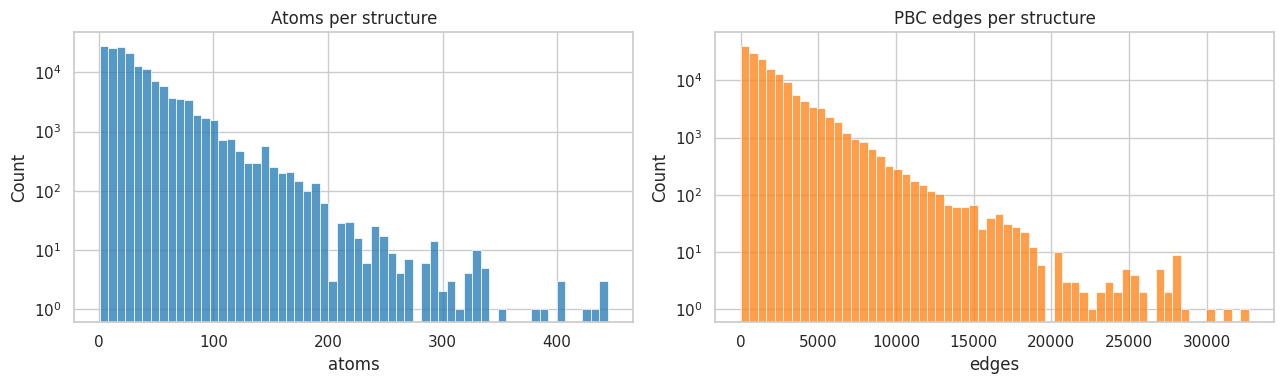

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

if metadata_nodes is not None:
    sns.histplot(metadata_nodes, bins=60, ax=axes[0], color="tab:blue")
    axes[0].set_title("Atoms per structure")
    axes[0].set_xlabel("atoms")
    axes[0].set_yscale("log")
else:
    axes[0].text(0.5, 0.5, "metadata_num-nodes.npz missing", ha="center")

if metadata_edges is not None:
    sns.histplot(metadata_edges, bins=60, ax=axes[1], color="tab:orange")
    axes[1].set_title("PBC edges per structure")
    axes[1].set_xlabel("edges")
    axes[1].set_yscale("log")
else:
    axes[1].text(0.5, 0.5, "metadata_num-edges.npz missing", ha="center")

plt.tight_layout()

## Structure, cell, and energy distributions

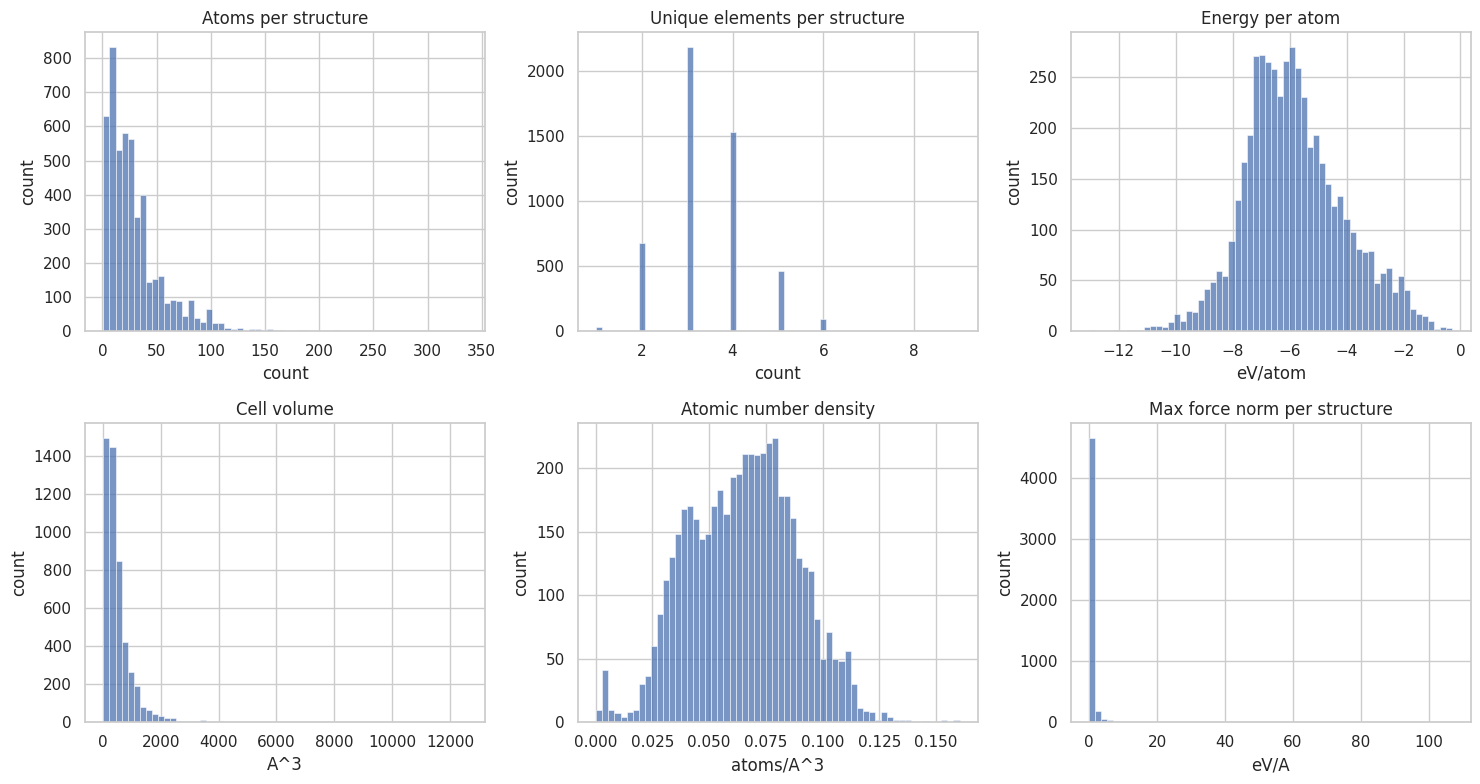

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plots = [
    ("natoms", "Atoms per structure", "count"),
    ("n_unique_elements", "Unique elements per structure", "count"),
    ("energy_per_atom", "Energy per atom", "eV/atom"),
    ("volume", "Cell volume", "A^3"),
    ("atoms_per_A3", "Atomic number density", "atoms/A^3"),
    ("force_max_norm", "Max force norm per structure", "eV/A"),
]

for ax, (col, title, xlabel) in zip(axes.ravel(), plots):
    sns.histplot(structure_df[col].replace([np.inf, -np.inf], np.nan).dropna(), bins=60, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("count")

plt.tight_layout()

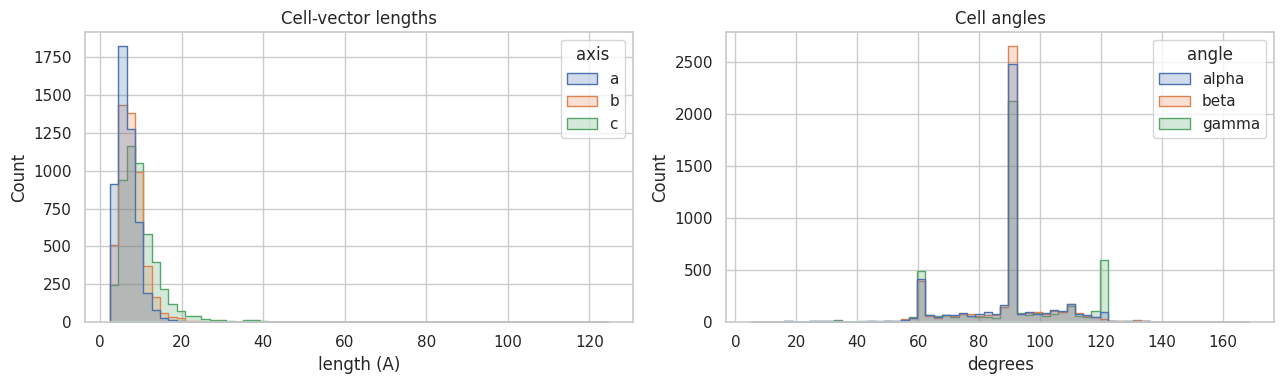

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

length_df = structure_df[["a", "b", "c"]].melt(var_name="axis", value_name="length")
sns.histplot(data=length_df, x="length", hue="axis", bins=60, element="step", stat="count", common_norm=False, ax=axes[0])
axes[0].set_title("Cell-vector lengths")
axes[0].set_xlabel("length (A)")

angle_df = structure_df[["alpha", "beta", "gamma"]].melt(var_name="angle", value_name="degrees")
sns.histplot(data=angle_df, x="degrees", hue="angle", bins=60, element="step", stat="count", common_norm=False, ax=axes[1])
axes[1].set_title("Cell angles")
axes[1].set_xlabel("degrees")

plt.tight_layout()

## Element composition

`atomic_numbers` is one of the core model inputs. This plot counts atoms by element in the sampled structures.

,Z,symbol,count
6,8,O,56637
11,1,H,8586
52,9,F,5919
10,16,S,5082
3,3,Li,4157
5,15,P,4034
1,12,Mg,3838
13,7,N,3566
12,6,C,3222
22,14,Si,3102


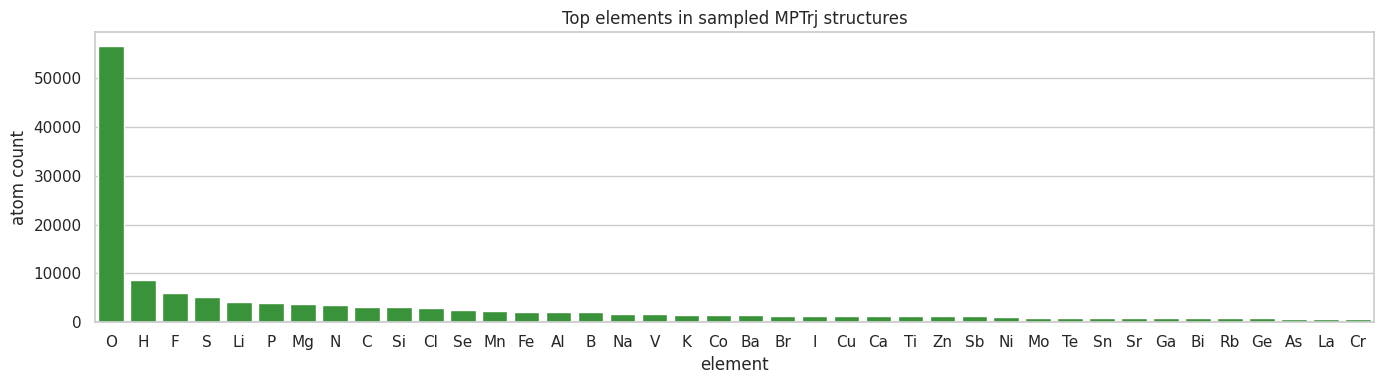

In [14]:
element_df = pd.DataFrame(
    [
        {"Z": z, "symbol": chemical_symbols[z], "count": count}
        for z, count in element_counter.items()
    ]
).sort_values("count", ascending=False)

display(element_df.head(30))

plt.figure(figsize=(14, 4))
sns.barplot(data=element_df.head(40), x="symbol", y="count", color="tab:green")
plt.title("Top elements in sampled MPTrj structures")
plt.xlabel("element")
plt.ylabel("atom count")
plt.xticks(rotation=0)
plt.tight_layout()

## Force label distributions

`forces` is an atom-level label during normal training. In DeNS mode, the same output key `forces` becomes a hybrid target: physical forces for uncorrupted atoms and `noise_vec` for corrupted atoms.

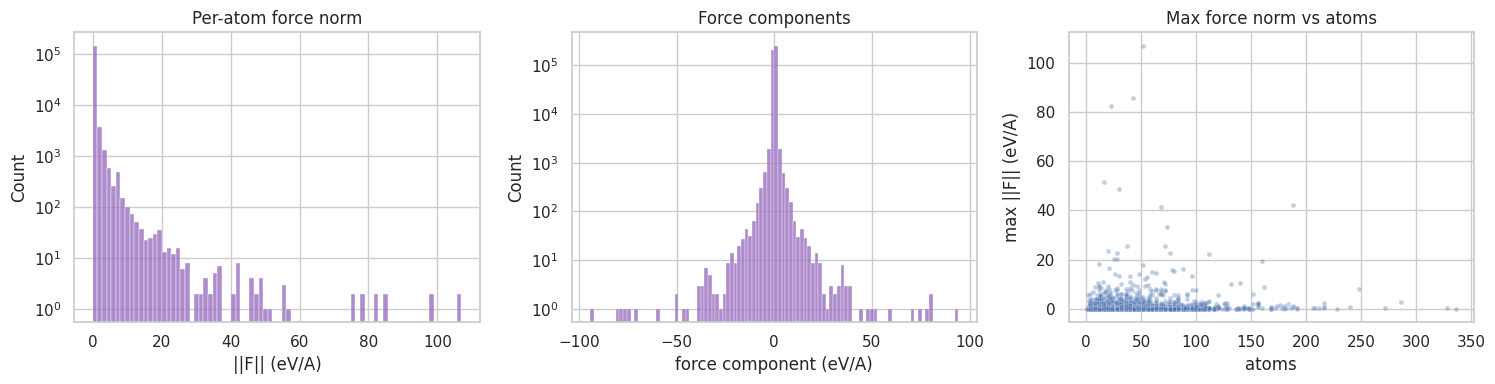

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(force_norms, bins=80, ax=axes[0], color="tab:purple")
axes[0].set_title("Per-atom force norm")
axes[0].set_xlabel("||F|| (eV/A)")
axes[0].set_yscale("log")

sns.histplot(force_components, bins=100, ax=axes[1], color="tab:purple")
axes[1].set_title("Force components")
axes[1].set_xlabel("force component (eV/A)")
axes[1].set_yscale("log")

sns.scatterplot(data=structure_df, x="natoms", y="force_max_norm", s=12, alpha=0.35, ax=axes[2])
axes[2].set_title("Max force norm vs atoms")
axes[2].set_xlabel("atoms")
axes[2].set_ylabel("max ||F|| (eV/A)")

plt.tight_layout()

## Stress label distributions

`stress` is stored as a `3 x 3` tensor on each sample and becomes `[3B, 3]` after PyG batching. The model's direct stress head returns `[B, 9]`, so the trainer reshapes targets to `[B, -1]` before loss/evaluation.

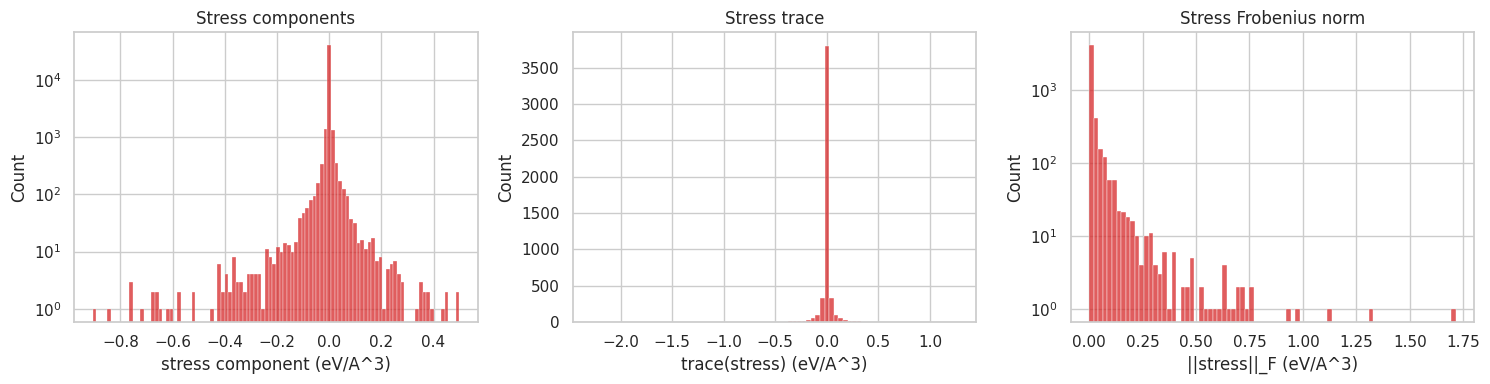

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(stress_components, bins=100, ax=axes[0], color="tab:red")
axes[0].set_title("Stress components")
axes[0].set_xlabel("stress component (eV/A^3)")
axes[0].set_yscale("log")

sns.histplot(structure_df["stress_trace"], bins=80, ax=axes[1], color="tab:red")
axes[1].set_title("Stress trace")
axes[1].set_xlabel("trace(stress) (eV/A^3)")

sns.histplot(structure_df["stress_fro_norm"], bins=80, ax=axes[2], color="tab:red")
axes[2].set_title("Stress Frobenius norm")
axes[2].set_xlabel("||stress||_F (eV/A^3)")
axes[2].set_yscale("log")

plt.tight_layout()

## Tags, fixed atoms, and PBC flags

This is where MPTrj differs from OC20-style adsorbate/surface datasets. The default ASE dataset transform sets tags to all `1` if no tags are present; those should not be interpreted as OC20 `0=bulk`, `1=surface`, `2=adsorbate` labels for this dataset. `fixed` is still used by the trainer as a force mask, but MPTrj structures usually have all atoms free.

,tag,count
0,1,153059


,fixed,count
0,0,153059


,pbc,count
0,TTT,5000


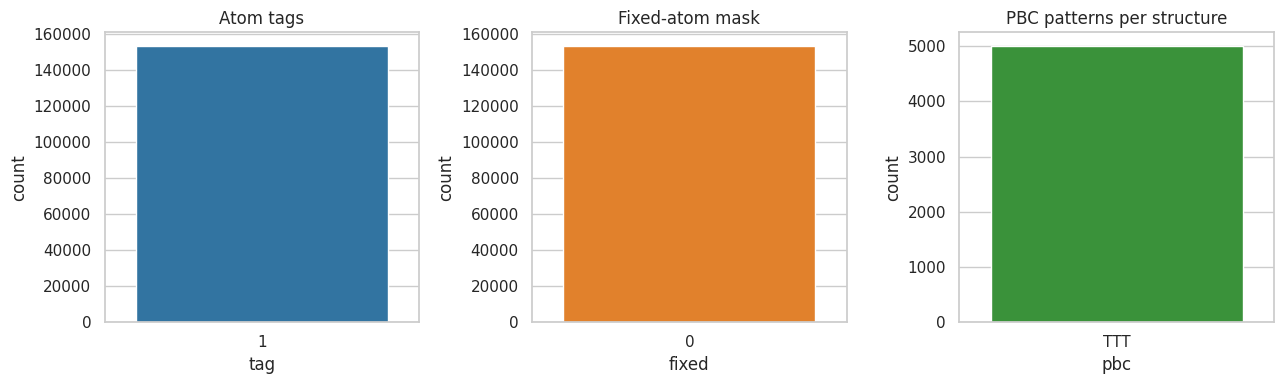

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

tag_df = pd.DataFrame([{"tag": k, "count": v} for k, v in sorted(tag_counter.items())])
fixed_df = pd.DataFrame([{"fixed": k, "count": v} for k, v in sorted(fixed_counter.items())])
pbc_df = pd.DataFrame([{"pbc": k, "count": v} for k, v in sorted(pbc_counter.items())])

sns.barplot(data=tag_df, x="tag", y="count", ax=axes[0], color="tab:blue")
axes[0].set_title("Atom tags")

sns.barplot(data=fixed_df, x="fixed", y="count", ax=axes[1], color="tab:orange")
axes[1].set_title("Fixed-atom mask")

sns.barplot(data=pbc_df, x="pbc", y="count", ax=axes[2], color="tab:green")
axes[2].set_title("PBC patterns per structure")

plt.tight_layout()

display(tag_df)
display(fixed_df)
display(pbc_df)

## On-the-fly periodic graph distributions

EquiformerV3 derives graph attributes during forward. This helper mirrors `GraphModelMixin.generate_graph` with `use_pbc_single=True`, which is the MPTrj training setting.

In [18]:
def build_pbc_graph_like_model(batch, cutoff=CUTOFF, max_neighbors=MAX_NEIGHBORS, use_pbc_single=USE_PBC_SINGLE):
    if use_pbc_single:
        pieces = [
            radius_graph_pbc(
                batch[i],
                cutoff,
                max_neighbors,
                ENFORCE_MAX_NEIGHBORS_STRICTLY,
            )
            for i in range(len(batch))
        ]
        edge_index_per_system, cell_offsets_per_system, neighbors_per_system = zip(*pieces)
        atom_index_offset = batch.natoms.cumsum(dim=0).roll(1)
        atom_index_offset[0] = 0
        edge_index = torch.hstack([
            edge_index_per_system[i] + atom_index_offset[i]
            for i in range(len(batch))
        ])
        cell_offsets = torch.vstack(cell_offsets_per_system)
        neighbors = torch.hstack(neighbors_per_system)
    else:
        edge_index, cell_offsets, neighbors = radius_graph_pbc(
            batch,
            cutoff,
            max_neighbors,
            ENFORCE_MAX_NEIGHBORS_STRICTLY,
        )

    out = get_pbc_distances(
        batch.pos,
        edge_index,
        batch.cell,
        cell_offsets,
        neighbors,
        return_offsets=True,
        return_distance_vec=True,
    )
    return out["edge_index"], out["distances"], out["distance_vec"], out["offsets"], neighbors


def chunked(values, chunk_size):
    for start in range(0, len(values), chunk_size):
        yield values[start:start + chunk_size]


graph_indices = sample_indices[: min(GRAPH_SAMPLE_SIZE, len(sample_indices))]
edge_rows = []
edge_distances = []
edge_offset_norms = []

for idx_chunk in tqdm(list(chunked(graph_indices, GRAPH_BATCH_SIZE)), desc="Building PBC graphs"):
    graph_batch = data_list_collater([dataset[int(i)] for i in idx_chunk], otf_graph=True)
    edge_index, distances, distance_vec, offsets, neighbors = build_pbc_graph_like_model(graph_batch)
    target_graph = graph_batch.batch[edge_index[1]].detach().cpu().numpy()
    edge_counts = np.bincount(target_graph, minlength=len(graph_batch))
    natoms_chunk = graph_batch.natoms.detach().cpu().numpy()

    for local_i, global_idx in enumerate(idx_chunk):
        edge_rows.append({
            "idx": int(global_idx),
            "natoms": int(natoms_chunk[local_i]),
            "edges": int(edge_counts[local_i]),
            "edges_per_atom": float(edge_counts[local_i] / natoms_chunk[local_i]),
        })

    edge_distances.extend(distances.detach().cpu().numpy().tolist())
    edge_offset_norms.extend(offsets.detach().cpu().norm(dim=1).numpy().tolist())

edge_df = pd.DataFrame(edge_rows)
edge_distances = np.asarray(edge_distances)
edge_offset_norms = np.asarray(edge_offset_norms)

edge_df.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T

Building PBC graphs: 100%|██████████| 32/32 [00:01<00:00, 18.15it/s]


,count,mean,std,min,50%,75%,90%,95%,99%,max
idx,512.0,7650.357422,4581.315365,30.0,7408.500000,11855.500000,13920.0000,14701.600000,15345.05,15439.000000
natoms,512.0,30.332031,28.092437,2.0,22.000000,38.500000,65.0000,84.000000,119.78,228.000000
edges,512.0,1837.726562,2039.199429,8.0,1321.000000,2432.500000,4285.8000,5353.400000,7192.32,22456.000000
edges_per_atom,512.0,56.454725,22.045921,2.0,58.278571,73.377404,82.7825,89.064286,99.98,119.142857


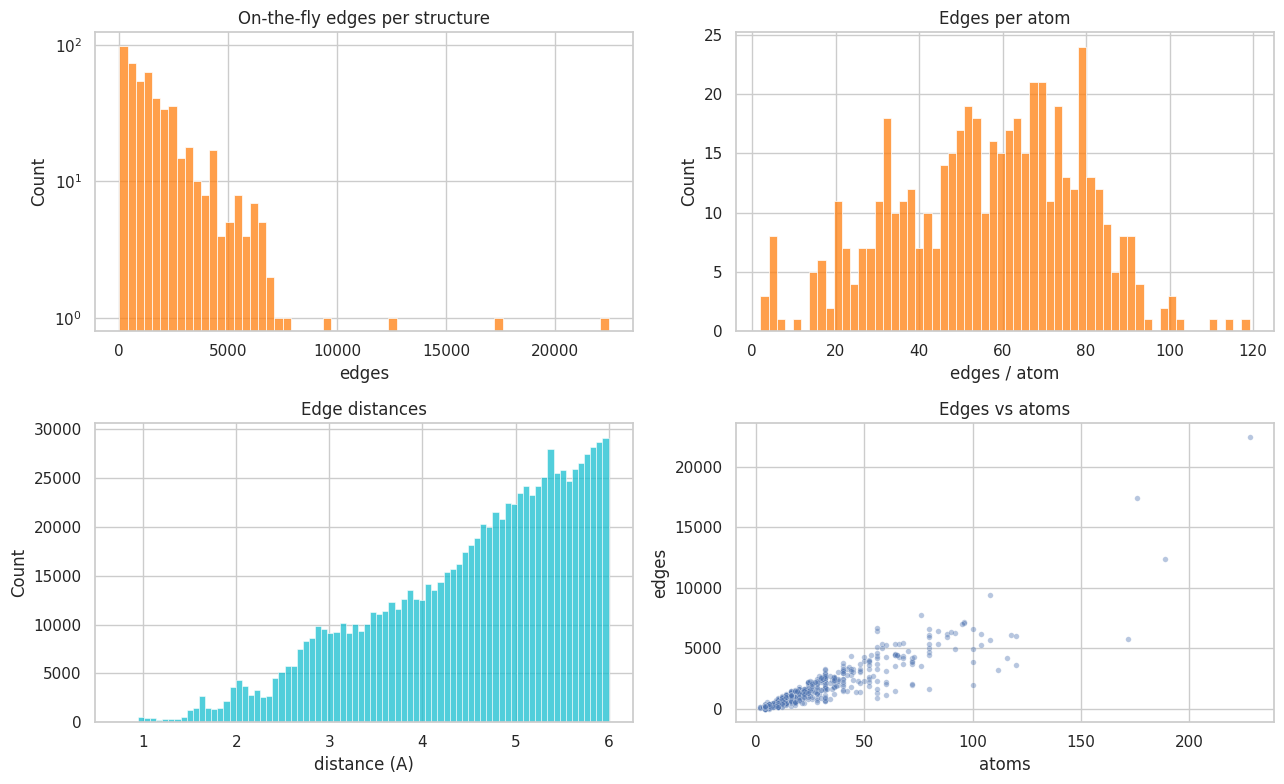

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.histplot(edge_df["edges"], bins=60, ax=axes[0, 0], color="tab:orange")
axes[0, 0].set_title("On-the-fly edges per structure")
axes[0, 0].set_xlabel("edges")
axes[0, 0].set_yscale("log")

sns.histplot(edge_df["edges_per_atom"], bins=60, ax=axes[0, 1], color="tab:orange")
axes[0, 1].set_title("Edges per atom")
axes[0, 1].set_xlabel("edges / atom")

sns.histplot(edge_distances, bins=80, ax=axes[1, 0], color="tab:cyan")
axes[1, 0].set_title("Edge distances")
axes[1, 0].set_xlabel("distance (A)")

sns.scatterplot(data=edge_df, x="natoms", y="edges", s=16, alpha=0.4, ax=axes[1, 1])
axes[1, 1].set_title("Edges vs atoms")
axes[1, 1].set_xlabel("atoms")
axes[1, 1].set_ylabel("edges")

plt.tight_layout()

## Corrections and checks against the preliminary Gemini explanation

- Correct for this repo: `atomic_numbers`, `pos`, `cell`, `pbc`, `natoms`, and PyG `batch` are core inputs; `energy`, `forces`, and `stress` are labels; `batch` and `ptr` are PyG batching attributes.
- Correct for batched shapes: `stress=[3B, 3]` and `pbc=[3B]` are PyG-collated versions of per-structure `[3, 3]` and `[3]` attributes.
- Needs MPTrj-specific correction: `tags` should not be interpreted as OC20 bulk/surface/adsorbate tags here. The default ASE transform sets all tags to `1` when tags are absent.
- Needs MPTrj-specific nuance: `fixed` is a trainer mask, but MPTrj bulk structures are generally all free atoms after this conversion.
- Needs DeNS nuance: `noise_vec`, `noise_mask`, `dens_batch_mask`, and `denoising_pos_forward` are created on the fly, not stored in ASE-LMDB. In DeNS mode, `forces` can also become a conditioning signal inside `equiformer_v3_dens`, while `noise_vec` is the denoising target for noisy atoms.
- Needs graph nuance: MPTrj ASE-LMDB does not provide model-ready edges for this config. Edges are derived during forward from the structure and PBC settings.